DSCI 552 Homework 6

Name: Brynn Dafoe GitHub Username: brynndafoe02 USD ID: 3109-6692-10

In [1]:
from imblearn.under_sampling import RandomUnderSampler
from itertools import combinations
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
import re

import seaborn as sns

from sklearn import datasets
from sklearn.datasets import make_classification, make_regression
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression, LogisticRegressionCV, RidgeCV, LassoCV
from sklearn.metrics import RocCurveDisplay, roc_auc_score, accuracy_score, classification_report, confusion_matrix, mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import GridSearchCV, train_test_split, StratifiedKFold, cross_val_score, RepeatedKFold, KFold
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.tree import DecisionTreeClassifier, plot_tree, _tree

from skmultilearn.problem_transform import LabelPowerset

import statsmodels.api as sm
import statsmodels.formula.api as smf

import xgboost as xgb

Question 1.b
- This data set has missing values
- When the number of data with missing values is significant, discarding them is not a good idea

In [2]:
# setting up dataframes, separating class labels from the predictors
training_df = pd.read_csv("../data/aps_failure_training_set.csv", skiprows=20, na_values = "na")
X_train_df = training_df.drop(columns=["class"])
Y_train_df = training_df["class"].map({"neg": 0, "pos": 1})

testing_df = pd.read_csv("../data/aps_failure_test_set.csv", skiprows=20, na_values = "na")
X_test_df = testing_df.drop(columns=["class"])
Y_test_df = testing_df["class"].map({"neg": 0, "pos": 1})


Question 1.b.i
- Research what types of techniques are usually used for dealing with data with missing values
- - They are called data imputation techniques
- Pick at least one of them and apply it to this data in the next steps
- - You are welcome to test more than one method

Common techniques:
- Mean Imputation (if data is distributed normally) -> 5-20% missing data, MCAR or MAR
- Median Imputation (if data is skewed) -> 5-20% missing data, MCAR or MAR
- Mode Imputation (if variables are categorical) -> 5-20% missing data, MCAR or MAR
- KNN Imputation (comp expensive for large datasets) -> more than 20%, MCAR or MAR
- Regression Imputation (when missing values can be predicted from other variables) -> 5-20% missing data, MCAR or MAR
- MICE (computationally intense) -> more than 20%, MCAR, MAR, or NMAR
- Random Sampling Imputation -> 5-20% missing data, MCAR or MAR

In [3]:
print("Number of missing data in entire training set:")
print(training_df.isna().sum().sum())
print("Percentage of missing data relative to entire set:")
print((training_df.isna().sum().sum())/(60000*171))

Number of missing data in entire training set:
850015
Percentage of missing data relative to entire set:
0.08284746588693957


In [4]:
with pd.option_context('display.max_rows', None):
    print(X_train_df.skew().sort_values(ascending=False))


cs_009    243.531177
cf_000    212.459407
co_000    212.459406
ad_000    212.459406
dh_000    202.907014
az_009    163.609146
ay_009    159.066837
ag_000    153.387555
dj_000    150.507647
cs_007    140.732294
cs_008    121.563916
ak_000    113.625497
as_000    111.732428
au_000    108.987809
df_000    108.938646
ct_000    107.031061
ay_001    102.415758
cn_009    101.075836
ag_009     98.288989
dz_000     92.410273
ea_000     91.230552
ae_000     90.588252
eg_000     89.029482
az_002     86.763535
db_000     83.627961
dg_000     76.812727
ag_001     76.076049
aj_000     75.075731
ef_000     73.432440
az_000     69.347485
cs_001     67.935911
ch_000     67.165468
cy_000     65.341916
ay_004     63.509322
az_007     63.194700
da_000     62.925455
az_008     62.461056
ay_000     59.621486
az_001     58.303989
at_000     57.316795
cn_000     56.637624
cz_000     55.757088
ay_002     53.640077
dl_000     53.369202
ba_008     53.345250
af_000     51.671770
ba_009     49.209881
dk_000     49

The training data set proves to be highly skewed to the right, therefore I will use median imputation because of the skewness and because the missing data is 8%.

In [5]:
train_median_impute = SimpleImputer(strategy="median")
X_train_df = pd.DataFrame(train_median_impute.fit_transform(X_train_df), columns=X_train_df.columns)

test_median_impute = SimpleImputer(strategy="median")
X_test_df = pd.DataFrame(test_median_impute.fit_transform(X_test_df), columns=X_test_df.columns)


Question 1.b.ii
- For each of the 170 features, calculate the coefficient of variation CV = s/m
- - s = sample standard deviation
  - m = sample mean

In [6]:
stddev_X_train = X_train_df.mean()
mean_X_train = X_train_df.std()
cv_X_train = stddev_X_train / mean_X_train
for cv in cv_X_train.sort_values(ascending=False):
    print(cv)

inf
1.4511432815615752
1.3917224270243642
1.3273308821019467
1.2620159430071662
1.2201051320775298
1.196113467206577
1.1775550936537837
1.1478940272894311
1.0998881040761705
1.073202623006476
0.9516622984628633
0.5796357029505284
0.5443036299928808
0.5316579848780736
0.4944826474661479
0.4667142502712549
0.46166560316250166
0.456220078930403
0.4444453864039699
0.44039707983843085
0.4402948516075045
0.4330297735834433
0.4328553381805185
0.4325755634591101
0.431035244096134
0.42648357714325813
0.4242775515940084
0.4176955693276122
0.4166486911499786
0.415800944338517
0.41580093843900373
0.41580091044960227
0.4157661459908342
0.408511385143838
0.4081883917629659
0.40800712714963333
0.3983528716094806
0.3981584199703732
0.3961570844386874
0.38865565496717264
0.3874579032129233
0.3855665417291182
0.38157979830789485
0.3814338263835544
0.3810329456168373
0.3804129861203289
0.3799766952036312
0.37068467657675613
0.37043032495296563
0.3659447082024701
0.3516030171844414
0.35128048594153627
0.3

One of the coefficients of variation is infinity, meaning its sample mean was 0 (so dividing by 0).

Question 1.b.iii
- Plot a correlation matrix for your features using pandas or any other tool

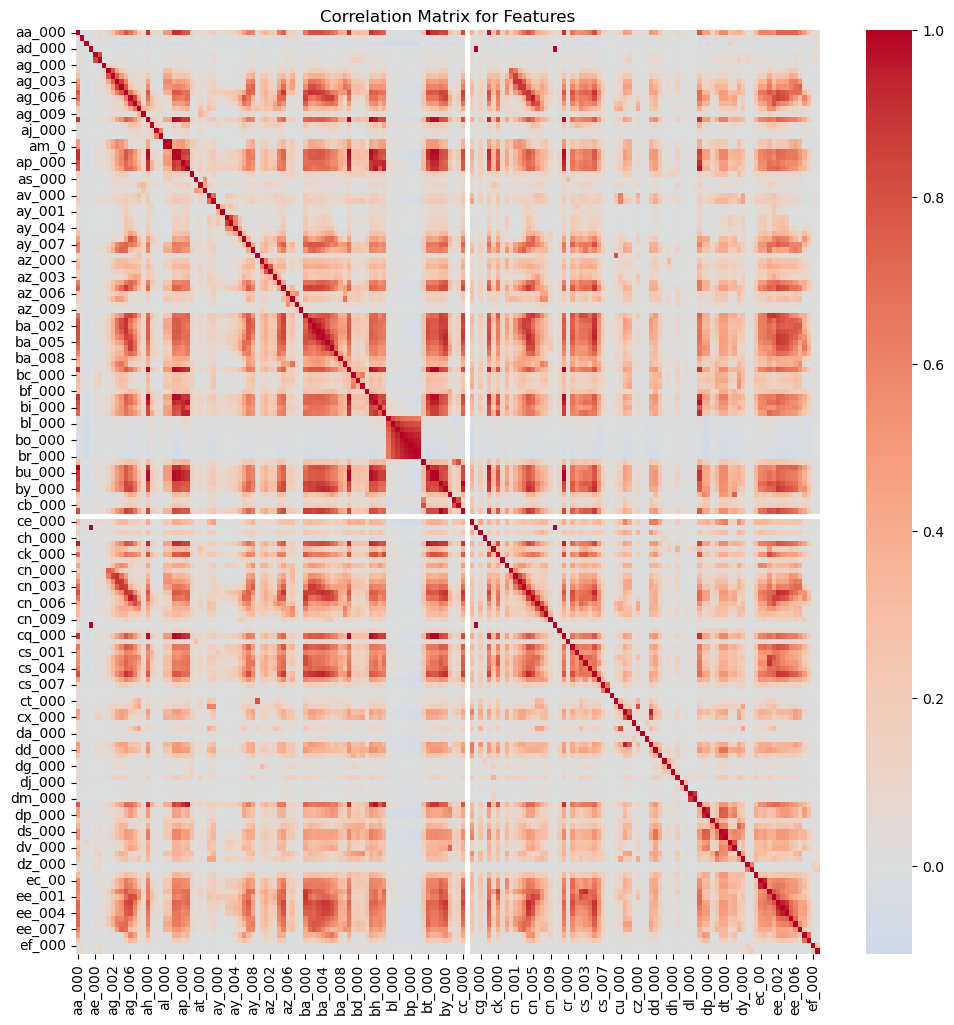

In [7]:
train_cm = X_train_df.corr()
plt.figure(figsize=(12, 12))
sns.heatmap(train_cm, cmap="coolwarm", center=0)
plt.title("Correlation Matrix for Features")
plt.show()


Question 1.b.iv
- Pick floorfun(sqrtrt(170)) features with highest CV, and make scatter plots and box plots for them, similar to those on p.129 of ISLR
- Can you draw conclusions about significance of those features, just by the scatter plots?
- This does not mean that you will only use those features in the following questions
- We pick them only for visualization

In [8]:
# CV part, use above
num_feats_highest_cv = math.floor(math.sqrt(170))
feats_highest_cv = cv_X_train.sort_values(ascending=False).head(num_feats_highest_cv)
print(feats_highest_cv)
print(f"Num of plots needed: {math.comb(num_feats_highest_cv, 2)}")

cd_000         inf
br_000    1.451143
bq_000    1.391722
bp_000    1.327331
bo_000    1.262016
bk_000    1.220105
bn_000    1.196113
bm_000    1.177555
bl_000    1.147894
cb_000    1.099888
ca_000    1.073203
bs_000    0.951662
dc_000    0.579636
dtype: float64
Num of plots needed: 78


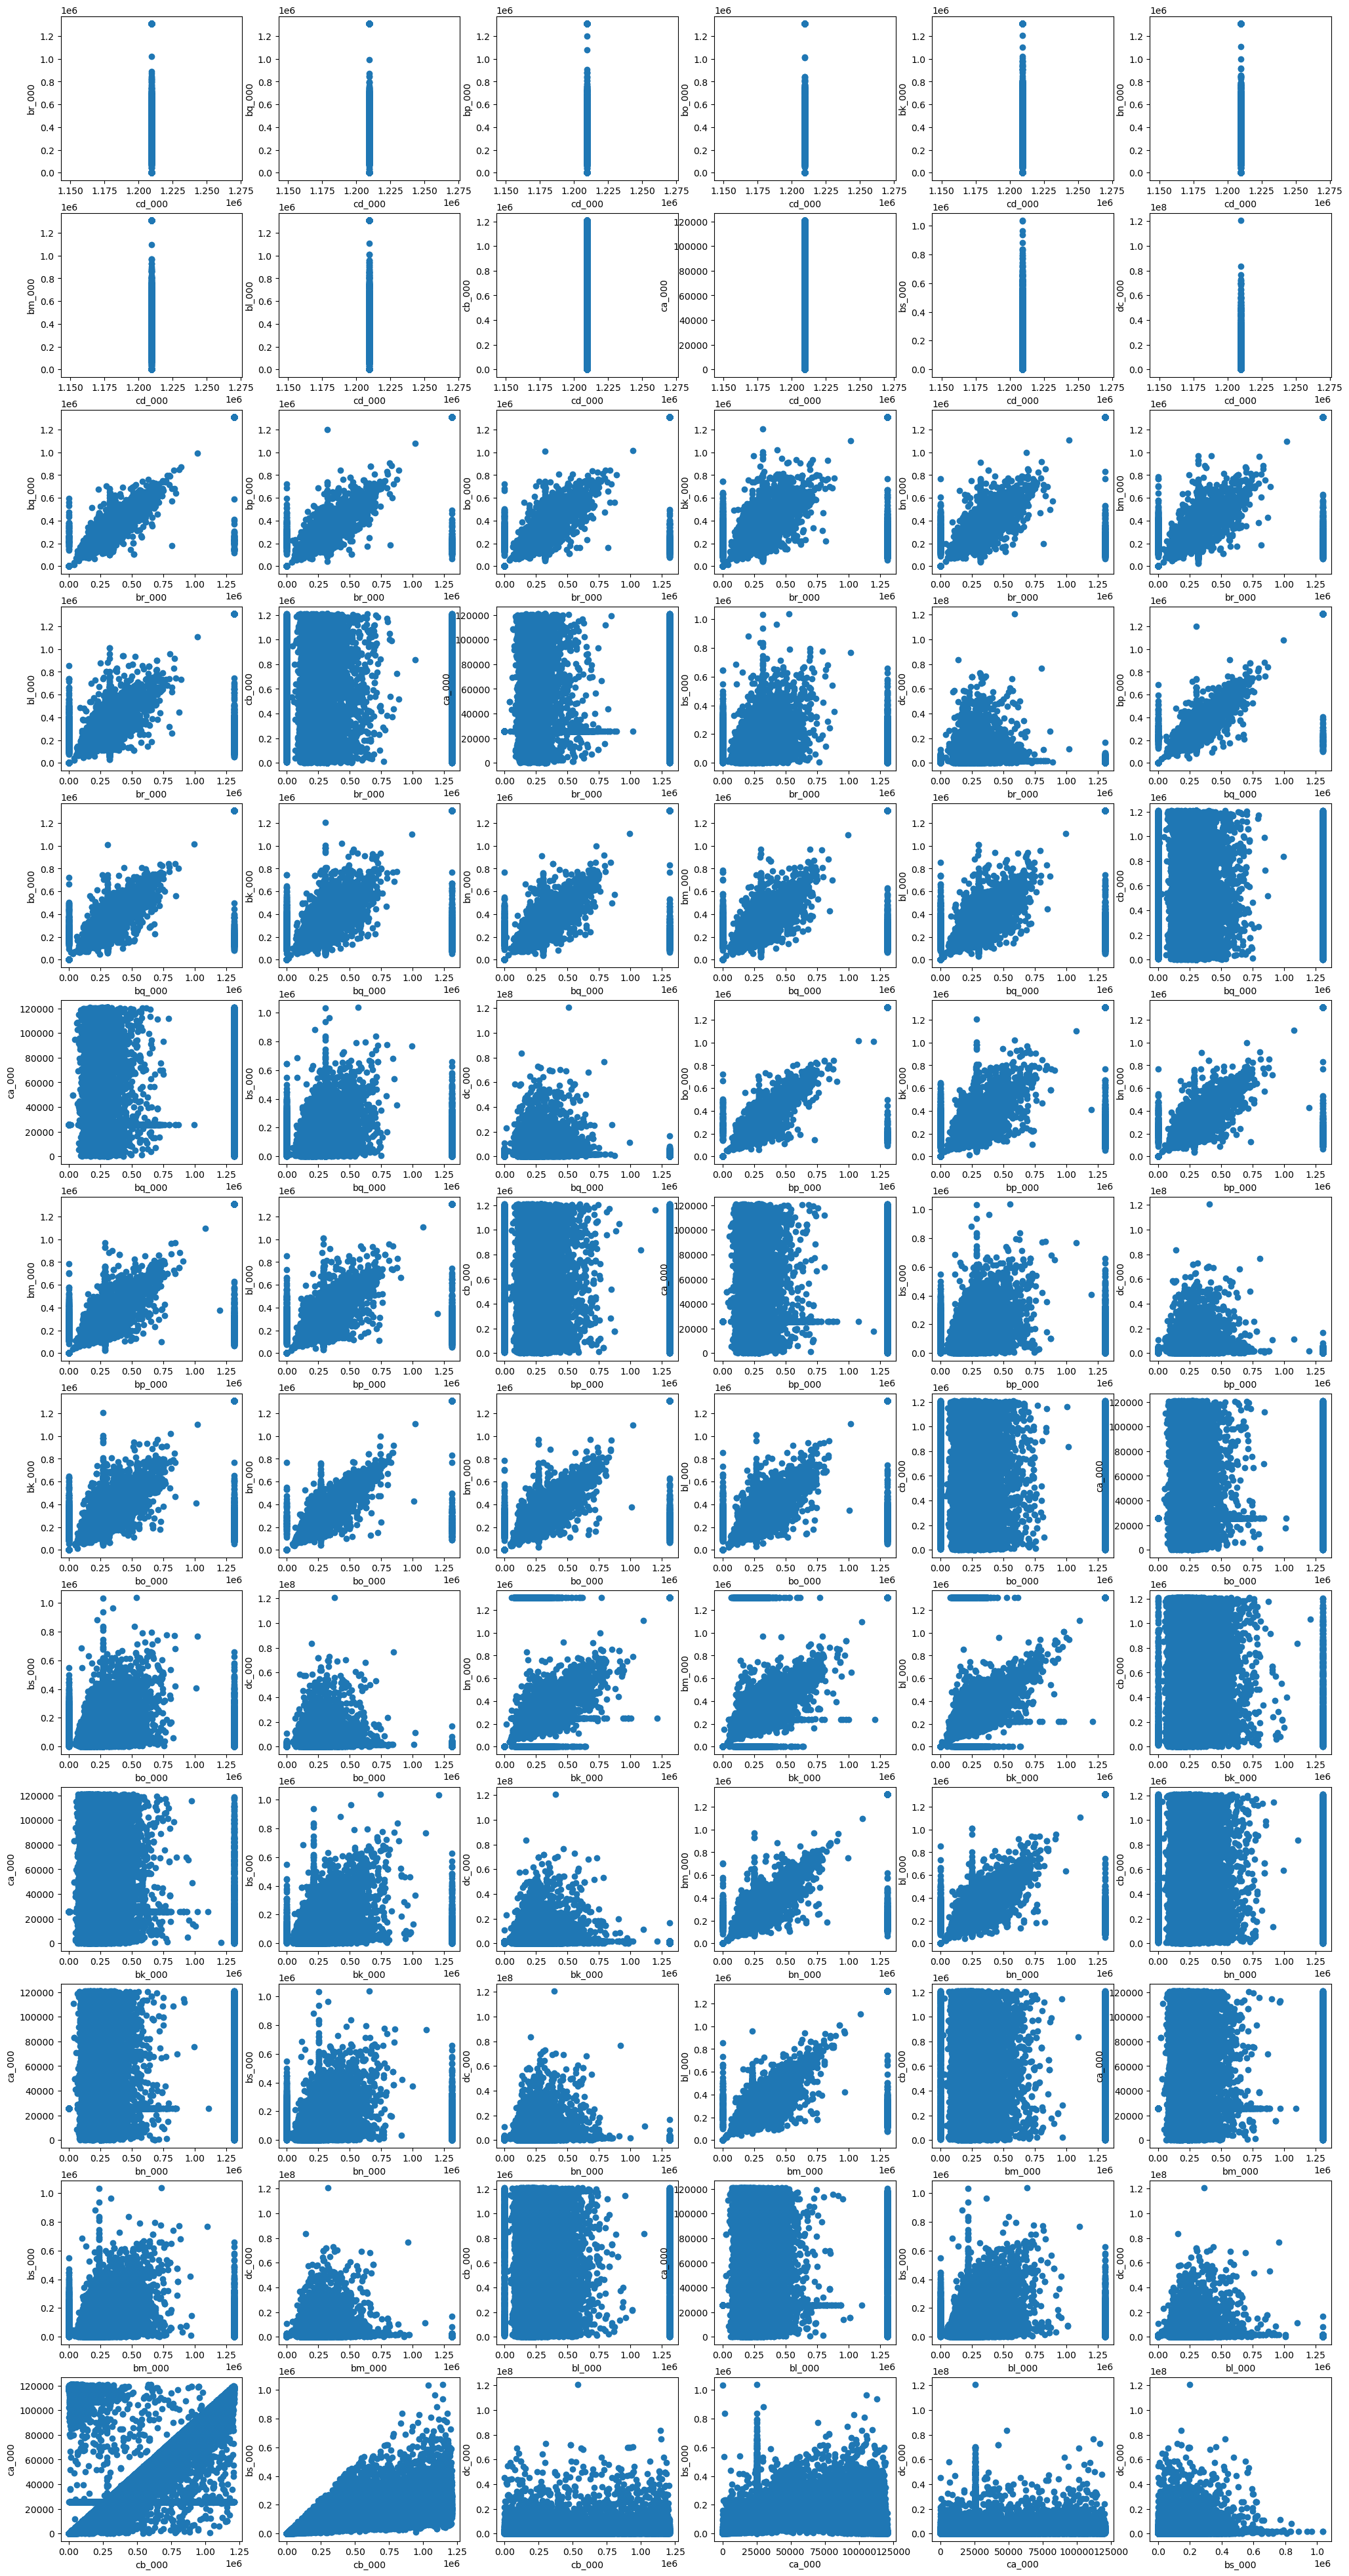

In [9]:
# Scatter Plots
fig, axes = plt.subplots(13, 6, figsize=(25, 50))
axes = axes.flatten()

feats_highest_cv_index = feats_highest_cv.index

diff_plot_num = 0

for first_feat in range(len(feats_highest_cv_index)):
    for second_feat in range(first_feat + 1, len(feats_highest_cv_index)):
        x_axis = feats_highest_cv_index[first_feat]
        y_axis = feats_highest_cv_index[second_feat]

        axes[diff_plot_num].scatter(X_train_df[x_axis], X_train_df[y_axis])
        axes[diff_plot_num].set_xlabel(x_axis)
        axes[diff_plot_num].set_ylabel(y_axis)
        diff_plot_num+=1
plt.show()

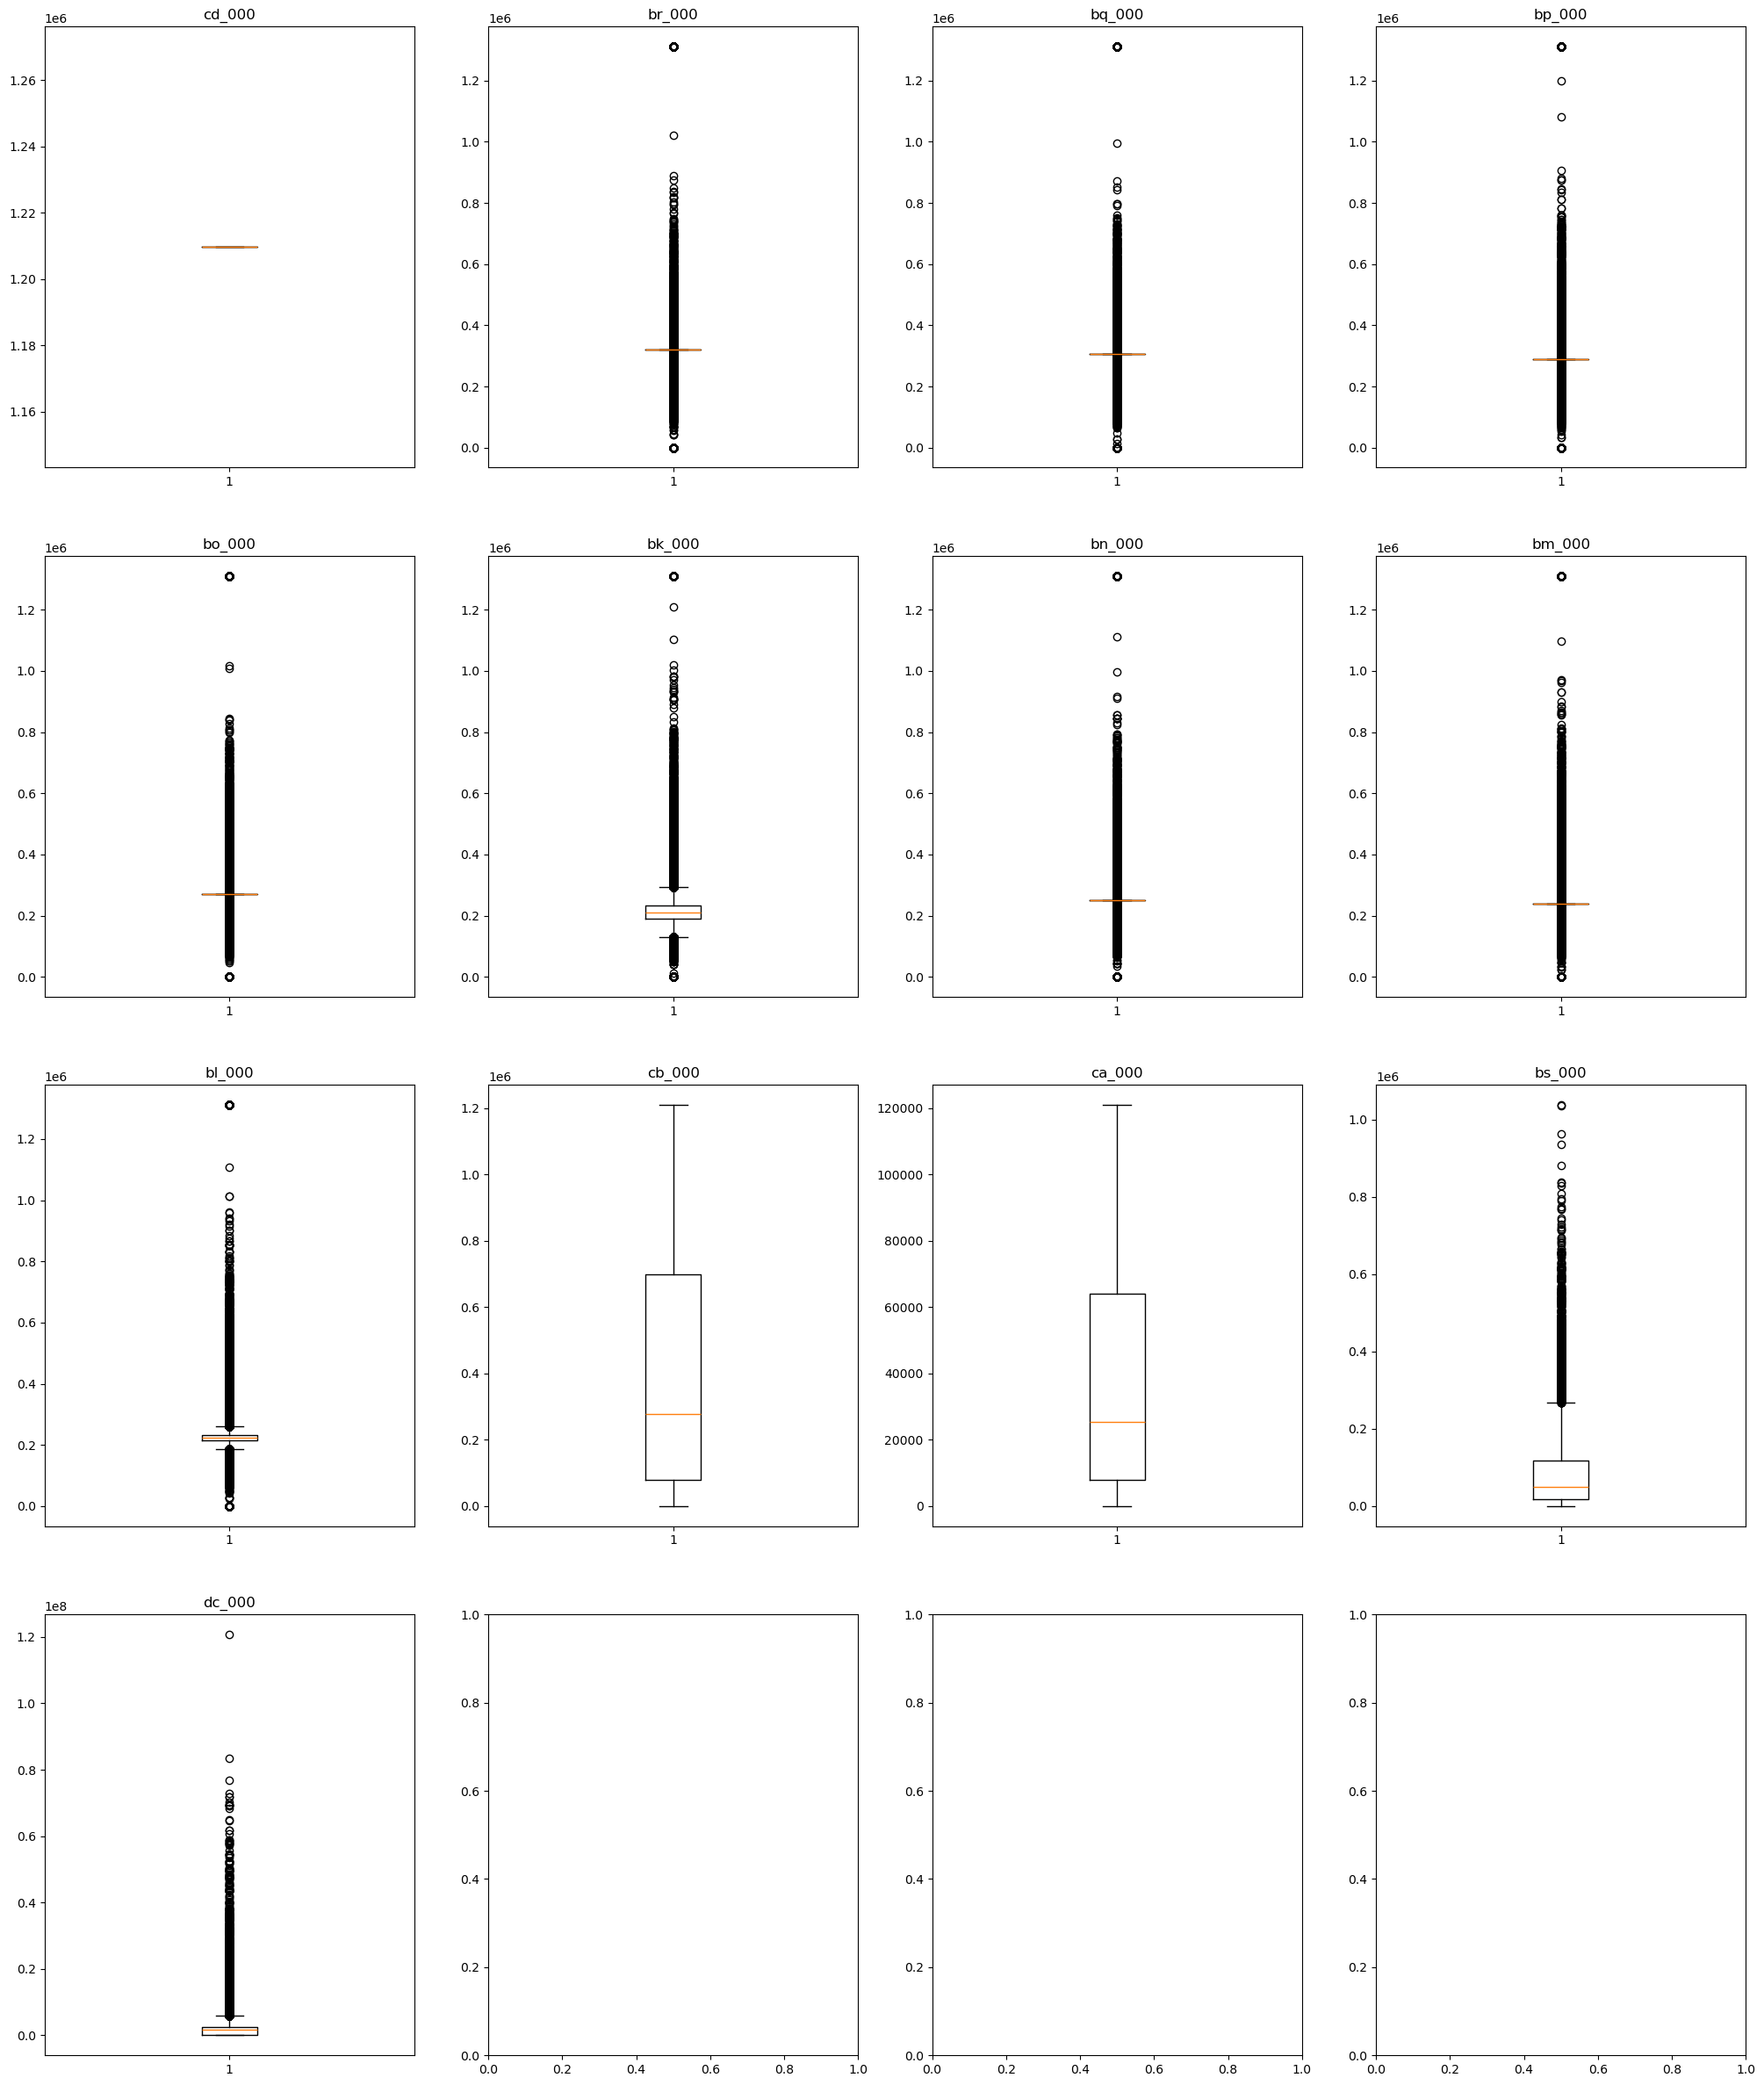

In [10]:
# Box Plots
fig, axes = plt.subplots(4, 4, figsize=(25, 30))
axes = axes.flatten()

for i in range(len(feats_highest_cv_index)):
    feat = feats_highest_cv_index[i]
    axes[i].boxplot(X_train_df[feat].dropna())
    axes[i].set_title(feat)
plt.show()

MY ANSWER:
- Some of the features in the scatterplots show stronger positive relationships such as row 4 column 6 (bp_000 x bq_000) and row 3 column 1 (bq_000 x br_000). 
- Many of them are looking to be skewed to the left / lower left corner. 
- Many of them have outliers
- A lot of them also have vertical lines or horizontal lines of values, showing possible repeated values. Some of these lines are in an area I would maybe consider outlier territory while some lines are in the area near the rest of the values
- The first two rows of the scatterplot grid shows features that have not variability at all, which I believe means they have little to no information about the relationship (I think this may be due to the feature that had "inf" as its CV)
- Obviously we cannot definitively say what the significance is, but the scatterplots do show signs of positive / weak / no relationship

Question 1.b.v
- Determine the number of positive and negative data
- Is his data set imbalanced?

In [11]:
print(Y_train_df.value_counts())

class
0    59000
1     1000
Name: count, dtype: int64


MY ANSWER:
- Yes, the data set is imbalanced with negative class having a much higher count

Question 1.c
- Train a random forest to classify the data set
- Do NOT compensate for class imbalance in the data set
- Calculate the confusion matrix, ROC, AUC, and misclassification for training and test sets and report them
- - You may use pROC package
- Calculate the Out of Bag error estimate for your random forest and compare it to the test error

In [14]:
randomforest = RandomForestClassifier(n_estimators=100, random_state=42, oob_score=True)
randomforest.fit(X_train_df, Y_train_df)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [34]:
training_preds_rf = randomforest.predict(X_train_df)
testing_preds_rf = randomforest.predict(X_test_df)
# train_prob = rf.predict_proba(X_train)[:, 1]
# test_prob = rf.predict_proba(X_test)[:, 1]

training_cmat = confusion_matrix(Y_train_df, training_preds_rf)
testing_cmat = confusion_matrix(Y_test_df, testing_preds_rf)

In [35]:
training_error_rf = 1 - accuracy_score(Y_train_df, training_preds_rf)
testing_error_rf = 1 - accuracy_score(Y_test_df, testing_preds_rf)


In [36]:
oob_score = randomforest.oob_score_
oob_error = 1 - oob_score

Training CM: 
[[59000     0]
 [    1   999]]

Testing CM: 
[[15610    15]
 [  106   269]]

Training Misclassification Error: 0.000017

Testing Misclassification Error: 0.007563
Out of Bag Error: 0.006117



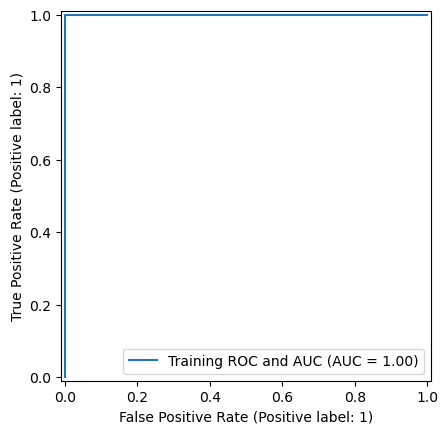

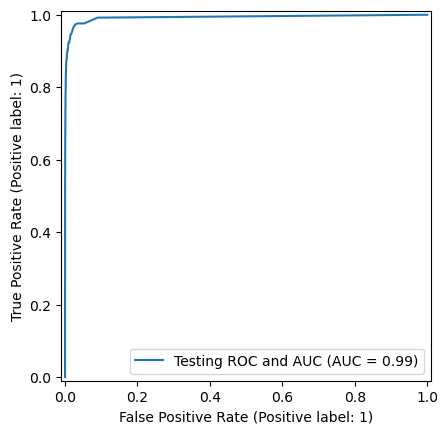

In [39]:
# All print outs for CM, ROC, AUC, Misclassification, and OOB Error
print(f"Training CM: \n{training_cmat}\n")
print(f"Testing CM: \n{testing_cmat}\n")
print(f"Training Misclassification Error: {training_error_rf:.6f}\n")
print(f"Testing Misclassification Error: {testing_error_rf:.6f}")
print(f"Out of Bag Error: {oob_error:.6f}\n")
RocCurveDisplay.from_estimator(randomforest, X_train_df, Y_train_df, name="Training ROC and AUC")
RocCurveDisplay.from_estimator(randomforest, X_test_df, Y_test_df, name="Testing ROC and AUC")


- The test misclassification error and OOB error are very close (0.007 compared to 0.006, respectively), which shows that the model generalizes well.